In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')

# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------


# The Wong&ndash;Sandler mixing rule &mdash; putting an activity coefficient model inside an equation of state

**Section 9.9.**

Two kinds of model have been built in this chapter and neither one covers the field.
A cubic equation of state with the van der Waals one-fluid rules (&sect;9.4) works at
any density and any temperature, in both phases &mdash; but only for simple mixtures,
hydrocarbons and inorganic gases. An activity coefficient model (&sect;&sect;9.5, 9.6)
handles any degree of nonideality, including polar organics &mdash; but only for the
*liquid*, only over a narrow temperature range, and only with a standard state that
becomes fictitious as soon as a component is supercritical.

&sect;9.9 combines them. The idea is that a cubic equation of state has **two**
constants, $a$ and $b$, so **two** conditions can be imposed:

1. at **low density**, the second virial coefficient must be quadratic in composition,
   as statistical mechanics requires;
2. at **liquid densities**, the excess Helmholtz energy must match an activity
   coefficient model.

**This is the one place in the book where the method being taught is the
author's own** (Wong and Sandler, *AIChE J.* **38**, 671, 1992). It is also
**prose only**: &sect;9.9 has no illustration, no figure, and not a single worked
number. So there is nothing here to check an implementation against &mdash; which makes
this notebook's job different from every other one in the chapter. Instead of
reproducing printed answers, it **checks the derivation against itself**: the two
conditions the mixing rule was built from are imposed at the start and verified as
arithmetic at the end.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from thermo import (WongSandler, GexFromUNIFAC, UNIFAC, PRMixture, PengRobinson,
                    C_STAR_PR, C_STAR_VDW)
from thermo.data import unifac_groups
from thermo.charts import use_book_style
use_book_style()
R = constants.R

## The two conditions, and the rule that comes out of them

**Low density.** From statistical mechanics the second virial coefficient of a mixture
is quadratic in composition (Eq. 9.9-1), and from a cubic equation of state it is
$B = b - a/RT$ (Eq. 9.9-2). Together:

$$b - \frac{a}{RT} = \sum_i\sum_j x_i x_j\left(b_{ij} - \frac{a_{ij}}{RT}\right)
\tag{9.9-3}$$

That fixes the *combination* $b - a/RT$, not $a$ and $b$ separately.

**Liquid density.** The excess energy from the equation of state must equal the one
from an activity coefficient model. It has to be the **Helmholtz** energy, not the
Gibbs energy, because $\underline G^{\rm ex} = \underline A^{\rm ex} +
P\underline V^{\rm ex}$ (Eq. 9.9-5) and the $P\underline V^{\rm ex}$ term diverges as
$P \to \infty$ while $\underline A^{\rm ex}$ barely moves:

$$\underline A^{\rm ex}_{\rm EOS}(T, P\to\infty, x)
 = \underline A^{\rm ex}_{\gamma}(T, P\to\infty, x)
 = \underline A^{\rm ex}_{\gamma}(T, P = 1\ {\rm bar}, x)
 = \underline G^{\rm ex}_{\gamma}(T, P = 1\ {\rm bar}, x)
\tag{9.9-7}$$

and for a cubic equation of state at infinite pressure (Problem 9.31)

$$\underline A^{\rm ex}_{\rm EOS} = C^*\left[\frac{a}{b} - \sum_i x_i\frac{a_i}{b_i}\right]
\tag{9.9-8}$$

Solving the two conditions together gives the **Wong&ndash;Sandler mixing rules**:

$$\frac{a}{RT} = \frac{QD}{1-D} \qquad b = \frac{Q}{1-D} \tag{9.9-9a}$$
$$Q = \sum_i\sum_j x_i x_j\left(b_{ij}-\frac{a_{ij}}{RT}\right) \tag{9.9-9b}$$
$$D = \sum_i x_i\frac{a_i}{b_i RT} + \frac{\underline G^{\rm ex}_{\gamma}(T,x)}{C^* RT}
\tag{9.9-9c}$$

In [3]:
print(f"C* for Peng-Robinson: ln(sqrt(2)-1)/sqrt(2) = {C_STAR_PR:.6f}"
      f"   (the book prints -0.62323)")
print(f"C* for van der Waals:                         {C_STAR_VDW:.6f}")

C* for Peng-Robinson: ln(sqrt(2)-1)/sqrt(2) = -0.623225   (the book prints -0.62323)
C* for van der Waals:                         -1.000000


## The mixture, and where $\underline G^{\rm ex}$ comes from

**Acetone + water at 25&nbsp;&deg;C** &mdash; the system &sect;10.3 uses for all four of
its demonstrations of this mixing rule, and about as nonideal as a miscible binary gets.

For $\underline G^{\rm ex}$ we use **UNIFAC**. That is not a convenience: it is the
fourth of the four routes &sect;10.3 lists, the *predictive* one, in which the mixing
rule is fed a group-contribution model so that a mixture with no data at all can be
carried to high temperature and pressure. It also means this notebook rests on two
things already verified elsewhere in the chapter rather than on fitted constants.

Acetone is not one of Table 9.5-2's example species, so its group assignment is
made here rather than looked up: acetone is $\rm CH_3CO + CH_3$, which is the table's
own 2-butanone entry (1 $\rm CH_3CO$, 1 $\rm CH_3$, 1 $\rm CH_2$) less the $\rm CH_2$.

In [4]:
ACETONE = {18: 1, 1: 1}                 # CH3CO + CH3
WATER = unifac_groups("water")          # {16: 1}, from Table 9.5-2's own examples
print("acetone groups:", ACETONE, "   water groups:", WATER)

gex = GexFromUNIFAC(UNIFAC(), [ACETONE, WATER])
T = 298.15
ws = WongSandler.from_database(["acetone", "water"], gex, kij=0.0)
print(ws)

x = np.array([0.4, 0.6])
print(f"\nat x_acetone = {x[0]}:")
print(f"  G^ex (UNIFAC)     = {gex.gex(x, T):9.3f} J/mol")
print(f"  Q                 = {ws.Q(x, T):12.6e} m^3/mol")
print(f"  D                 = {ws.D(x, T):9.4f}")
print(f"  b                 = {ws.b_mix(x, T):12.6e} m^3/mol")
print(f"  a                 = {ws.a_mix(x, T):9.4f} Pa m^6/mol^2")

acetone groups: {18: 1, 1: 1}    water groups: {16: 1}
WongSandler([acetone, water], GexFromUNIFAC, combining='9.9-10b')

at x_acetone = 0.4:
  G^ex (UNIFAC)     =  1082.546 J/mol
  Q                 = -5.635968e-04 m^3/mol
  D                 =   17.5417
  b                 = 3.407118e-05 m^3/mol
  a                 =    1.4816 Pa m^6/mol^2


**$D > 1$, and that is not a bug.** $1-D$ is a denominator in Eq. 9.9-9a, so the
instinct is to expect $D < 1$. But $D$ is dominated by $\sum_i x_i a_i/(b_i RT)$, which
is about 12 for liquid water at 25&nbsp;&deg;C and exceeds 1 for any fluid below its
Boyle temperature. $Q$ is negative for the same reason &mdash; it is an average of
second virial coefficients, and those are negative here &mdash; and the two negatives
divide to a positive $b$. The pure-component limit is the proof, below.

In [5]:
print("pure-component limit -- the mixing rule must give back b_i and a_i exactly:\n")
eps = 1e-10
for i, name in enumerate(("acetone", "water")):
    xp = np.array([1 - eps, eps]) if i == 0 else np.array([eps, 1 - eps])
    pr = ws.components[i]
    print(f"  {name:8s} b: {ws.b_mix(xp, T):.10e} vs {pr.b:.10e}  "
          f"rel {abs(ws.b_mix(xp, T)/pr.b - 1):.1e}")
    print(f"  {name:8s} a: {ws.a_mix(xp, T):.10e} vs {pr.a(T):.10e}  "
          f"rel {abs(ws.a_mix(xp, T)/pr.a(T) - 1):.1e}")

pure-component limit -- the mixing rule must give back b_i and a_i exactly:

  acetone  b: 6.9930256142e-05 vs 6.9930256149e-05  rel 1.0e-10
  acetone  a: 2.4649877154e+00 vs 2.4649877156e+00  rel 7.6e-11
  water    b: 1.8929287462e-05 vs 1.8929287459e-05  rel 1.6e-10
  water    a: 9.8187933214e-01 vs 9.8187933203e-01  rel 1.1e-10


## Condition 1 and condition 2, as arithmetic

The mixing rules were *derived* by imposing Eqs. 9.9-3 and 9.9-4, so their holding is
not evidence that the derivation is right &mdash; it is evidence that this
implementation of it is. With no printed number in the section, that is the strongest
internal test available, and it is run at several compositions rather than
one.

In [6]:
print(f"{'x_acetone':>10} {'Eq. 9.9-3 (virial)':>20} {'Eqs. 9.9-4/-8 (A^ex)':>22} {'diagonal':>10}")
for x1 in (0.001, 0.1, 0.25, 0.5, 0.75, 0.9, 0.999):
    r = ws.check_boundary([x1, 1 - x1], T)
    print(f"{x1:10.3f} {r['virial']:20.2e} {r['helmholtz']:22.2e} {r['diagonal']:10.2e}")
print("\n(relative residuals; 'diagonal' is the combining rule reducing to b_i - a_i/RT)")

 x_acetone   Eq. 9.9-3 (virial)   Eqs. 9.9-4/-8 (A^ex)   diagonal
     0.001             1.44e-16               6.23e-13   0.00e+00
     0.100             1.29e-16               6.18e-15   0.00e+00
     0.250             0.00e+00               9.51e-15   0.00e+00
     0.500             1.76e-16               3.46e-15   0.00e+00
     0.750             1.42e-16               5.25e-15   0.00e+00
     0.900             1.26e-16               4.33e-15   0.00e+00
     0.999             0.00e+00               2.97e-13   0.00e+00

(relative residuals; 'diagonal' is the combining rule reducing to b_i - a_i/RT)


## The infinite-pressure limit, which is the whole argument

Condition 2 rests on three claims the section makes in words:

- $\underline G^{\rm ex}$ **diverges** as $P\to\infty$, because of the
  $P\underline V^{\rm ex}$ term;
- $\underline A^{\rm ex}$ **does not**, so it is $\underline A^{\rm ex}$ that should be
  matched;
- and in that limit the equation of state gives Eq. 9.9-8, with $C^*$ = &minus;0.62323
  for Peng&ndash;Robinson.

None of that is checked anywhere in the book &mdash; Eq. 9.9-8 is left as Problem 9.31.
It can be checked here, by computing the excess properties **from the equation of state
directly** at rising pressure and watching where they go:

$$\underline G^{\rm ex} = RT\sum_i x_i\left[\ln\bar\phi_i^{\rm mix} - \ln\phi_i^{\rm pure}\right]
\qquad
\underline A^{\rm ex} = \underline G^{\rm ex} - P\underline V^{\rm ex}$$

In [7]:
def excess_from_eos(P, x=x, phase="liquid"):
    # G^ex, V^ex and A^ex computed from the equation of state itself, J/mol.
    lnphi_mix = ws.ln_phi(x, T, P, phase)
    lnphi_pure = np.array([c.ln_phi(T, P, phase) for c in ws.components])
    Gex = R * T * float(x @ (lnphi_mix - lnphi_pure))
    Vex = ws.molar_volume(x, T, P, phase) - float(
        x @ np.array([c.molar_volume(T, P, phase) for c in ws.components]))
    return Gex, Vex, Gex - P * Vex

target = ws.excess_helmholtz(x, T)      # Eq. 9.9-8
print(f"Eq. 9.9-8 says A^ex(P->inf) = C*[a/b - sum x_i a_i/b_i] = {target:.6f} J/mol")
print(f"and Eq. 9.9-7 says that must equal G^ex from UNIFAC     = {gex.gex(x, T):.6f} J/mol\n")
print(f"{'P (bar)':>10} {'G^ex (EOS)':>16} {'P V^ex':>16} {'A^ex (EOS)':>13} {'rel. err':>10}")
Ps = np.array([1e0, 1e1, 1e2, 1e3, 1e5, 1e7, 1e9, 1e11])
Aex = []
for Pb in Ps:
    G, V, A = excess_from_eos(Pb * 1e5)
    Aex.append(A)
    print(f"{Pb:10.0e} {G:16.2f} {Pb*1e5*V:16.2f} {A:13.4f} {abs(A/target-1):10.2e}")
Aex = np.array(Aex)

Eq. 9.9-8 says A^ex(P->inf) = C*[a/b - sum x_i a_i/b_i] = 1082.546384 J/mol
and Eq. 9.9-7 says that must equal G^ex from UNIFAC     = 1082.546384 J/mol

   P (bar)       G^ex (EOS)           P V^ex    A^ex (EOS)   rel. err
     1e+00           867.16            -0.71      867.8713   1.98e-01
     1e+01           860.78            -7.07      867.8551   1.98e-01
     1e+02           798.34           -68.13      866.4686   2.00e-01
     1e+03           247.57          -570.01      817.5814   2.45e-01
     1e+05        -51563.58        -52531.87      968.2966   1.06e-01
     1e+07      -5257410.64      -5258491.77     1081.1379   1.30e-03
     1e+09    -525848165.23    -525849247.77     1082.5323   1.30e-05
     1e+11  -52584923694.86  -52584924777.41     1082.5466   1.58e-07


**The section's argument is exactly right, and now it has numbers.**
$\underline G^{\rm ex}$ runs off to $-5\times10^{10}$ J/mol while
$\underline A^{\rm ex}$ walks onto Eq. 9.9-8's value and stays there &mdash;
agreeing to **seven figures** at $10^{11}$ bar. That simultaneously verifies Eq. 9.9-8,
the Peng&ndash;Robinson value of $C^*$ (Problem 9.31's answer), and the choice of
Helmholtz over Gibbs.

**But look at how good the second approximation actually is.** Eq. 9.9-6
replaces $\underline A^{\rm ex}(P\to\infty)$ with $\underline A^{\rm ex}$ at 1 bar, on
the grounds that $\underline A^{\rm ex}$ is "only a weak function of pressure at liquid
densities." Weak is not zero: for this system the two differ by the amount printed
below. That difference is not an error in the method &mdash; it is the method's central
approximation, and its size is printed below rather than left as "insensitive" on
trust.

In [8]:
A_1bar = Aex[0]
print(f"A^ex at 1 bar          : {A_1bar:9.3f} J/mol")
print(f"A^ex as P -> infinity  : {target:9.3f} J/mol")
print(f"the Eq. 9.9-6 approximation is therefore good to "
      f"{abs(A_1bar/target - 1)*100:.1f}% for acetone/water at 25 C")

A^ex at 1 bar          :   867.871 J/mol
A^ex as P -> infinity  :  1082.546 J/mol
the Eq. 9.9-6 approximation is therefore good to 19.8% for acetone/water at 25 C


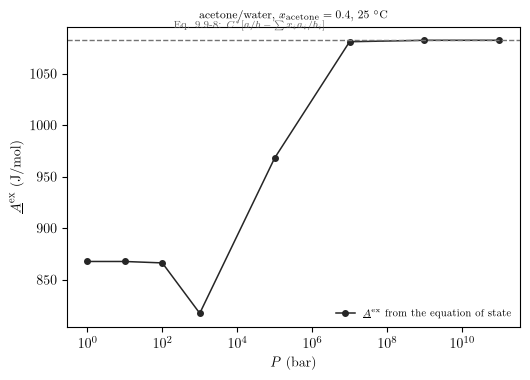

In [9]:
fig, ax = plt.subplots(figsize=(5.4, 3.9))
ax.semilogx(Ps, Aex, "o-", color="0.15", lw=1.1, ms=4,
            label=r"$\underline{A}^{\rm ex}$ from the equation of state")
ax.axhline(target, ls="--", color="0.45", lw=1.0)
ax.text(2e2, target + 12, r"Eq. 9.9-8: $C^*[a/b - \sum x_i a_i/b_i]$",
        fontsize=7, color="0.35")
ax.set_xlabel(r"$P$ (bar)"); ax.set_ylabel(r"$\underline{A}^{\rm ex}$ (J/mol)")
ax.set_title(r"acetone/water, $x_{\rm acetone}=0.4$, 25 $^\circ$C", fontsize=8)
ax.legend(frameon=False, fontsize=7, loc="lower right")
fig.tight_layout()

## Does the check have teeth?

A consistency check that cannot fail is decoration. This one can: $C^*$ appears in
Eq. 9.9-9c, where it sets how strongly $\underline G^{\rm ex}$ enters $D$, and again in
Eq. 9.9-8. Build the mixing rule with the **van der Waals** $C^*$ and then ask for the
Peng&ndash;Robinson excess Helmholtz energy, and the two conditions no longer agree.

In [10]:
ws_wrong = WongSandler.from_database(["acetone", "water"], gex, kij=0.0,
                                     C_star=C_STAR_VDW)   # wrong C* for a PR EOS
a_w, b_w = ws_wrong.a_mix(x, T), ws_wrong.b_mix(x, T)
a_i = ws_wrong.a_pure(T); b_i = ws_wrong.b_pure
A_pr = C_STAR_PR * (a_w / b_w - float(x @ (a_i / b_i)))   # PR's Eq. 9.9-8 on vdW's rule

print(f"G^ex the model should reproduce      : {gex.gex(x, T):9.3f} J/mol")
print(f"A^ex from Eq. 9.9-8 with PR's C*     : {A_pr:9.3f} J/mol")
print(f"  -> mismatch                        : {abs(A_pr/gex.gex(x,T) - 1)*100:9.1f}%")
print(f"\nwith the matching C*, the same check returns "
      f"{ws.check_boundary(x, T)['helmholtz']:.1e}")

G^ex the model should reproduce      :  1082.546 J/mol
A^ex from Eq. 9.9-8 with PR's C*     :   674.670 J/mol
  -> mismatch                        :      37.7%

with the matching C*, the same check returns 2.5e-15


## What this does to the composition dependence

The van der Waals one-fluid rules *assume* the composition dependence: $b$ linear,
$a$ quadratic, because those are the simplest choices. The Wong&ndash;Sandler rules
**derive** it &mdash; both come out of $Q/(1-D)$, and $D$ carries the whole activity
coefficient model. So the shapes need not be the same, and where they differ is the
mixing rule doing its work.

  b    departs from the van der Waals form by up to  13.5%  (at x_acetone = 0.35)
  a    departs from the van der Waals form by up to   0.9%  (at x_acetone = 0.40)
  a/b  departs from the van der Waals form by up to  14.6%  (at x_acetone = 0.35)


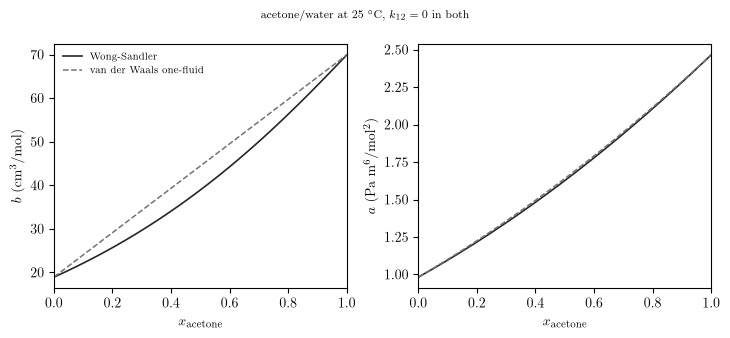

In [11]:
x1 = np.linspace(0.001, 0.999, 200)
prm = PRMixture([PengRobinson.from_database(k) for k in ("acetone", "water")])  # kij = 0

b_ws = np.array([ws.b_mix([a, 1 - a], T) for a in x1])
a_ws = np.array([ws.a_mix([a, 1 - a], T) for a in x1])
b_vdw = np.array([prm.b_mix([a, 1 - a]) for a in x1])
a_vdw = np.array([prm.a_mix([a, 1 - a], T) for a in x1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.4, 3.4))
ax1.plot(x1, b_ws * 1e6, "-", color="0.15", lw=1.2, label="Wong-Sandler")
ax1.plot(x1, b_vdw * 1e6, "--", color="0.45", lw=1.1, label="van der Waals one-fluid")
ax1.set_xlabel(r"$x_{\rm acetone}$"); ax1.set_ylabel(r"$b$ (cm$^3$/mol)")
ax1.legend(frameon=False, fontsize=7)
ax2.plot(x1, a_ws, "-", color="0.15", lw=1.2)
ax2.plot(x1, a_vdw, "--", color="0.45", lw=1.1)
ax2.set_xlabel(r"$x_{\rm acetone}$"); ax2.set_ylabel(r"$a$ (Pa m$^6$/mol$^2$)")
for ax in (ax1, ax2):
    ax.set_xlim(0, 1)
fig.suptitle(r"acetone/water at 25 $^\circ$C, $k_{12}=0$ in both", fontsize=8)
fig.tight_layout()

for label, w, v in (("b", b_ws, b_vdw), ("a", a_ws, a_vdw),
                    ("a/b", a_ws/b_ws, a_vdw/b_vdw)):
    dev = (w - v) / v
    print(f"  {label:4s} departs from the van der Waals form by up to "
          f"{np.max(np.abs(dev))*100:5.1f}%  (at x_acetone = "
          f"{x1[np.argmax(np.abs(dev))]:.2f})")

**It is $b$ that carries the difference, not $a$.** Look at the numbers: over the
whole composition range $a$ departs from the van der Waals quadratic by under 1%, while
$b$ departs from the linear form by 13.5%. That is not what one would guess from
Eq. 9.9-9a, where $a$ and $b$ look symmetrically placed &mdash; but $a = RTbD$, so the
two are locked together, and $D$ is large enough here that the correction lands almost
entirely on $b$. The group that actually feeds Eq. 9.9-8 is the **ratio** $a/b$, and that
moves by 14.6%.

So a reader who checks only the $a$ curve would conclude the mixing rule barely
does anything. The excess Helmholtz energy is built from $a/b$, and $b$ is where it lives.

**And both curves are drawn with $k_{12}=0$.** &sect;10.3 makes a point of this:
*"setting $k_{12} = 0$ is not equivalent to assuming ideal solution behavior."* With the
van der Waals rules it very nearly is &mdash; $k_{12}=0$ leaves
$a_{ij} = \sqrt{a_i a_j}$, the geometric mean, and little nonideality. Here $D$ still
carries the whole of $\underline G^{\rm ex}$, so a zero binary parameter still produces
a strongly nonideal mixture. The gap between the solid and dashed curves above *is*
that statement.

## The fugacity coefficient

$$\ln\bar\phi_i = \frac{1}{b}\left(\frac{\partial Nb}{\partial N_i}\right)(Z-1)
- \ln\left(Z - \frac{bP}{RT}\right)
- \frac{a}{2\sqrt2\,bRT}\left[\frac{1}{aN}\left(\frac{\partial N^2a}{\partial N_i}\right)
- \frac{1}{b}\left(\frac{\partial Nb}{\partial N_i}\right)\right]
\ln\left[\frac{Z+(1+\sqrt2)\frac{bP}{RT}}{Z+(1-\sqrt2)\frac{bP}{RT}}\right]
\tag{9.9-11}$$

This is the *general* cubic-mixture result, written with composition derivatives instead
of with $b_i$ and $2\sum_j x_j a_{ij}$ &mdash; for the van der Waals rules those are the
same thing, which gives a way to test it. The derivatives are Eqs. 9.9-12 and 9.9-13,
and the neat part is the last one:

$$\left(\frac{\partial ND}{\partial N_i}\right) = \frac{a_i}{b_i RT}
+ \frac{\ln\gamma_i}{C^*} \tag{9.9-13}$$

Differentiating $N\underline G^{\rm ex}$ with respect to $N_i$ gives $RT\ln\gamma_i$ by
definition, so **the activity coefficient model enters the fugacity coefficient as
itself** &mdash; no numerical differentiation, and any model with a $\gamma$ can be
dropped in. That is what makes the method practical, and it is why the book can say
these equations are "easily programmed."

In [12]:
P = 1.0e5
print("ln phi-bar_i for acetone/water at 25 C, 1 bar:")
for phase in ("liquid", "vapor"):
    print(f"  {phase:7s} {ws.ln_phi(x, T, P, phase)}")

print("\nEuler identities -- the derivatives must sum back to the properties:")
print(f"  sum x_i d(Nb)/dN_i  = {x @ ws.dNb_dNi(x, T):.10e}   b   = {ws.b_mix(x, T):.10e}")
print(f"  sum x_i d(N2a)/dN_i = {x @ ws.dN2a_dNi(x, T):.10e}   2a  = {2*ws.a_mix(x, T):.10e}")
print(f"  sum x_i d(ND)/dN_i  = {x @ ws.dND_dNi(x, T):.10e}   D   = {ws.D(x, T):.10e}")

ln phi-bar_i for acetone/water at 25 C, 1 bar:
  liquid  [-0.70344461 -3.35895666]
  vapor   [-0.03580711 -0.01440564]

Euler identities -- the derivatives must sum back to the properties:
  sum x_i d(Nb)/dN_i  = 3.4071182457e-05   b   = 3.4071182457e-05
  sum x_i d(N2a)/dN_i = 2.9631864424e+00   2a  = 2.9631864424e+00
  sum x_i d(ND)/dN_i  = 1.7541744347e+01   D   = 1.7541744347e+01


In [13]:
# The analytic derivatives of Eqs. 9.9-12 and 9.9-13, against central differences
# taken on the mole numbers themselves.
def prop(N, which):
    N = np.asarray(N, float); Nt = N.sum(); xx = N / Nt
    return {"Nb": Nt * ws.b_mix(xx, T),
            "N2a": Nt**2 * ws.a_mix(xx, T),
            "ND": Nt * ws.D(xx, T)}[which]

h = 1e-7
print("Eqs. 9.9-12 and 9.9-13 against numerical differentiation:\n")
for which, analytic in (("Nb", ws.dNb_dNi(x, T)),
                        ("N2a", ws.dN2a_dNi(x, T)),
                        ("ND", ws.dND_dNi(x, T))):
    num = np.array([(prop(x + h*np.eye(2)[i], which)
                     - prop(x - h*np.eye(2)[i], which)) / (2*h) for i in range(2)])
    print(f"  d({which})/dN_i  max relative difference: "
          f"{np.max(np.abs(num/analytic - 1)):.1e}")

Eqs. 9.9-12 and 9.9-13 against numerical differentiation:

  d(Nb)/dN_i  max relative difference: 2.7e-10
  d(N2a)/dN_i  max relative difference: 5.0e-10
  d(ND)/dN_i  max relative difference: 4.0e-10


### The test that reaches outside this notebook

Eq. 9.9-11 claims to be the general cubic-mixture fugacity coefficient. If that is true,
then feeding it the **van der Waals one-fluid** $a$, $b$ and their derivatives &mdash;
where $\partial(Nb)/\partial N_i = b_i$ and
$\partial(N^2a)/\partial N_i = 2\sum_j x_j a_{ij}$ &mdash; must reproduce `PRMixture`,
which was verified against **Illustration 9.4-3** back in &sect;9.4.

That is the one check here that does not depend on &sect;9.9 being right.

In [14]:
class VdW1fThroughWongSandler(WongSandler):
    # Eq. 9.9-11 driven by the van der Waals one-fluid rules instead of 9.9-9.
    def __init__(self, components, kij):
        super().__init__(components, gex=None, kij=kij)
    def _aij(self, T):
        a = self.a_pure(T)
        return (1 - self.kij) * np.sqrt(np.outer(a, a))
    def a_mix(self, x, T):  return float(self._x(x) @ self._aij(T) @ self._x(x))
    def b_mix(self, x, T):  return float(self._x(x) @ self.b_pure)
    def dNb_dNi(self, x, T):  return self.b_pure
    def dN2a_dNi(self, x, T): return 2.0 * (self._aij(T) @ self._x(x))

from thermo.data import pr_kij_matrix
keys = ["ethane", "n-butane"]                      # Illustration 9.4-3's mixture
kij_tab, _ = pr_kij_matrix(keys)
comps = [PengRobinson.from_database(k) for k in keys]
gen, ref = VdW1fThroughWongSandler(comps, kij_tab), PRMixture(comps, kij=kij_tab)

print("equimolar ethane / n-butane at 373.15 K (Illustration 9.4-3):\n")
print(f"{'P (bar)':>8} {'Eq. 9.9-11':>34} {'PRMixture (Eq. 9.4-9)':>34} {'max|diff|':>11}")
for Pb in (1, 10, 15):
    A = gen.ln_phi([0.5, 0.5], 373.15, Pb*1e5, "vapor")
    B = ref.ln_phi([0.5, 0.5], 373.15, Pb*1e5, "vapor")
    print(f"{Pb:8.0f} {str(np.round(A,10)):>34} {str(np.round(B,10)):>34} "
          f"{np.max(np.abs(A-B)):11.1e}")

equimolar ethane / n-butane at 373.15 K (Illustration 9.4-3):

 P (bar)                         Eq. 9.9-11              PRMixture (Eq. 9.4-9)   max|diff|
       1          [-0.00346755 -0.01387144]          [-0.00346755 -0.01387144]     9.6e-17
      10          [-0.03340729 -0.14328222]          [-0.03340729 -0.14328222]     0.0e+00
      15          [-0.04869783 -0.21945641]          [-0.04869783 -0.21945641]     2.6e-16


## What is not here, and where it is

**No phase equilibrium.** &sect;9.9 stops at the mixing rule and its fugacity
coefficient; the section's closing sentence is *"This will be demonstrated in the next
chapter."* &sect;10.3 does the demonstrating &mdash; Figs. 10.3-9 through 10.3-13, all on
this same acetone/water system &mdash; and it needs bubble- and dew-point drivers that
belong to Chapter 10, not here. `WongSandler` supplies the `ln_phi` those drivers call.

**Use PRSV for real work.** &sect;10.3 opens by saying that the generalized
$\kappa$ of Eq. 6.7-4 should be replaced by Eqs. 7.5-1 and 7.5-2 with $\kappa_1$ fitted
to each pure vapor pressure, "to ensure that the pure component vapor pressures are
correct." This notebook uses the generalized $\kappa$, because it is comparing mixing
rules rather than predicting a phase diagram &mdash; but a mixing rule cannot repair a
pure-component vapor pressure, and every VLE calculation should start from PRSV.
`PengRobinson.from_database(name, kappa1=...)` does that, and `WongSandler` takes the
resulting objects unchanged.

**Your turn.**

1. Both combining rules of Eq. 9.9-10 are implemented (`combining='9.9-10a'` and
   `'9.9-10b'`). Run the boundary checks for both and compare $a(x)$ and $b(x)$. How
   much does the choice matter compared with, say, moving $k_{12}$ from 0 to 0.1?
2. Swap UNIFAC for a correlative model &mdash; `NRTL` with $\alpha = 0.35$ is what
   &sect;10.3 uses for this system. What changes, and what does not?
3. Take $T$ from 298 K to 473 K at fixed composition and watch $b$. The van der Waals
   $b$ is temperature independent by construction; this one is not. Should it be?
4. Find the temperature at which $D = 1$ for this mixture, if there is one, and
   work out what happens to $a$ and $b$ near it. What does that tell you about the range
   over which the mixing rule can be used?

## Related

- [`UNIFAC_benzene_TMP_example.ipynb`](UNIFAC_benzene_TMP_example.ipynb) &mdash; the
  $\underline G^{\rm ex}$ model this notebook drops into the equation of state.
- [`PR_species_fugacity_ethane_butane_example.ipynb`](PR_species_fugacity_ethane_butane_example.ipynb)
  &mdash; the van der Waals one-fluid rules, and Illustration 9.4-3, which the last
  check here leans on.